In [16]:
# analytics on total damge incurred ona distrcit 


import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
import numpy as np
import warnings
warnings.filterwarnings("ignore")



In [2]:
CSV_PATH     = "jal shakti.csv"
GEOJSON_PATH = "hp_tehsil_final.geojson"
OUT_GEOJSON  = "jal_shakti_district_joined.geojson"
OUT_CSV      = "district_damage_summary.csv"
OUT_PNG      = "jal_shakti_analysis.png"

df =pd.read_csv(CSV_PATH)
gdf =gpd.read_file(GEOJSON_PATH)


In [3]:
district_name_map = {
    "LAHAUL AND SPITI": "LAHAUL & SPITI",
    "DHARAMSALA":       "KANGRA",   # Dharamsala is part of Kangra
}

df["District_norm"] = df["District"].str.upper().str.strip().replace(district_name_map)
gdf["District_norm"] = gdf["District"].str.upper().str.strip()

In [4]:
COMP_COLS = {
    "GI Distribution Pipe":   "Distribution _ GI Damage Estimate",
    "HDPE Distribution Pipe": "Distribution_HDPE_Damage Estimate",
    "GI Mains Pipe":          "Mains Pipe _GI_Dmage Estimate",
    "HDPE Mains Pipe":        "HDPE_main Damage Estimate",
    "Tubewell (Total)":       "Damage Estimate - Tubewell- Totally Damaged (INR)",
    "Spring Source (Total)":  "Spring Source _Totally Damage Estimate",
    "Spring Source (Partial)":"Spring Source _Partially Damage Estimate",
    "Handpump":               "Damage Estimate - Handpump  (INR)",
    "Pump Replacement (40HP)":"Damage Estimate - for 40 HP Pumps rate of 75000",
    "Pump Repair":            "Damaga Estimate - repair of Pumps",
    "Reservoir (Full)":       "Damage Estimate_Fully Damaged Reservoir",
    "Filtration Plant (Full)":"Filteration Plan -Fully Damage Estimate",
}
 
agg_dict = {
    "Sr. No.":                    "count",
    "Total Damage Estimate":      "sum",
    "Damage Estimate in lakhs":   "sum",
    "Population Catered":         "sum",
    "No of Villages Covered":     "sum",
    "No of habitations covered":  "sum",
}



In [5]:
for v in COMP_COLS.values():
     agg_dict[v] = "sum"
        
dist_dmg = df.groupby("District_norm").agg(agg_dict).reset_index()
dist_dmg.rename(columns={"District_norm": "District",
    "Sr. No.":                    "Incidents",
    "Total Damage Estimate":      "Damage_INR",
    "Damage Estimate in lakhs":   "Damage_Lakhs",
    "Population Catered":         "Pop_Catered",
    "No of Villages Covered":     "Villages",
    "No of habitations covered":  "Habitations"}, inplace =True)

for k, v in COMP_COLS.items():
    dist_dmg.rename(columns={v: k}, inplace=True)
    

In [7]:
dist_dmg["Damage_Crore"] = dist_dmg["Damage_INR"] / 1e7


#spatial join 
gdf_dist = ( gdf.dissolve(by= "District_norm").reset_index()[["District_norm", "geometry"]].rename(columns={"District_norm": "District"})
)
joined = gdf_dist.merge(dist_dmg,on ="District",how="left")
joined.to_file(OUT_GEOJSON, driver="GeoJSON")
dist_dmg.to_csv(OUT_CSV, index=False)
print(f"  → Saved: {OUT_GEOJSON}")
print(f"  → Saved: {OUT_CSV}")

  → Saved: jal_shakti_district_joined.geojson
  → Saved: district_damage_summary.csv


In [8]:
#-------------------------------------
#Summary Analysis
#-------------------------------------

total_cr  = dist_dmg["Damage_INR"].sum() / 1e7
total_inc = dist_dmg["Incidents"].sum()
top_dist  = dist_dmg.sort_values("Damage_Crore", ascending=False).iloc[0]
 
print("\n" + "="*60)
print("  DAMAGE SUMMARY — HIMACHAL PRADESH (JAL SHAKTI 2025)")
print("="*60)
print(f"  Total Damage        : ₹ {total_cr:,.2f} Crore")
print(f"  Total Incidents     : {total_inc:,}")
print(f"  Districts Affected  : {len(dist_dmg)}")
print(f"  Population Catered  : {dist_dmg['Pop_Catered'].sum():,.0f}")
print(f"  Villages Affected   : {int(dist_dmg['Villages'].sum()):,}")
print(f"  Habitations Affected: {int(dist_dmg['Habitations'].sum()):,}")
print(f"\n  Hardest Hit District: {top_dist['District']}")
print(f"    Damage   : ₹ {top_dist['Damage_Crore']:.2f} Crore")
print(f"    Incidents: {top_dist['Incidents']}")
print("="*60)
 
print("\n  District Ranking by Total Damage (₹ Crore):")
print(f"  {'District':<20} {'Damage (Cr)':>12} {'Incidents':>10} {'Villages':>10}")
print("  " + "-"*54)
for _, row in dist_dmg.sort_values("Damage_Crore", ascending=False).iterrows():
    print(f"  {row['District']:<20} {row['Damage_Crore']:>12.2f} {row['Incidents']:>10} {int(row['Villages']):>10}")


  DAMAGE SUMMARY — HIMACHAL PRADESH (JAL SHAKTI 2025)
  Total Damage        : ₹ 547.78 Crore
  Total Incidents     : 8,789
  Districts Affected  : 12
  Population Catered  : 20,901,674
  Villages Affected   : 59,200
  Habitations Affected: 140,135

  Hardest Hit District: MANDI
    Damage   : ₹ 100.40 Crore
    Incidents: 1818

  District Ranking by Total Damage (₹ Crore):
  District              Damage (Cr)  Incidents   Villages
  ------------------------------------------------------
  MANDI                      100.40       1818      11316
  CHAMBA                      98.28       1041       4221
  KULLU                       65.99       1199       2372
  HAMIRPUR                    61.89        433      13700
  SIRMAUR                     49.89        645       1670
  KANGRA                      48.12        849       8904
  SHIMLA                      37.93        815       3427
  BILASPUR                    35.49        702       6175
  SOLAN                       22.31        6

In [9]:
dis_type = (
    df.groupby("Disaster Type")["Total Damage Estimate"]
      .sum().sort_values(ascending=False)
)
print("\n  Damage by Disaster Type:")
print(f"  {'Type':<35} {'INR':>18} {'Crore':>8}")
print("  " + "-"*63)
for dtype, val in dis_type.items():
    print(f"  {dtype:<35} {val:>18,.0f} {val/1e7:>8.2f}")


  Damage by Disaster Type:
  Type                                               INR    Crore
  ---------------------------------------------------------------
  Excessive Rain                           1,757,640,157   175.76
  Flash flood                              1,387,373,922   138.74
  Landslide                                1,207,614,530   120.76
  Flood                                      772,784,386    77.28
  Cloudburst                                 298,295,913    29.83
  Coldwave                                    13,596,000     1.36
  Fall from tree or steep-rock                13,137,660     1.31
  Lightening                                  12,101,440     1.21
  Sinking of Land                              4,004,720     0.40
  Land Strom                                   2,729,410     0.27
  Honey bees, Hornet, Wasps attack             2,621,331     0.26
  Avalanche                                    2,353,920     0.24
  Epidemics                                    1

In [14]:
DARK   = "#0f1117"
PANEL  = "#1a1d27"
GRID   = "#2a2d3a"
TEXT   = "#e8eaf0"
ACCENT = "#4fc3f7"
ORANGE = "#ffa726"
 

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

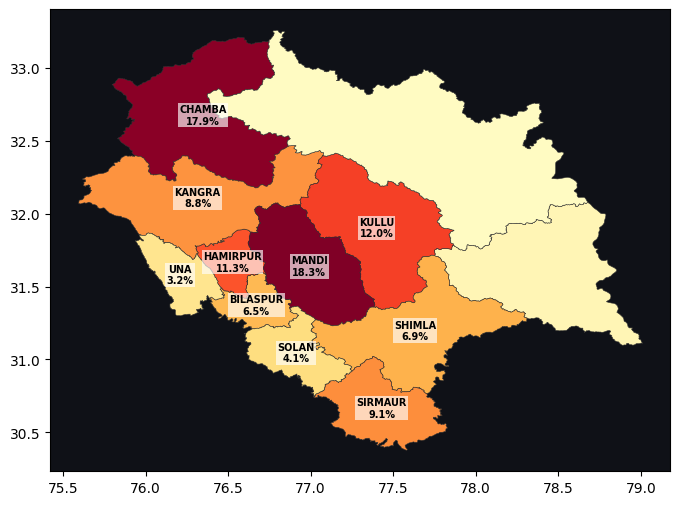

In [25]:
plt.figure(figsize=(8,6))
ax_map = plt.gca()
ax_map.set_facecolor(DARK)

import numpy as np
import matplotlib.ticker as mticker

# --- Color scale ---
cmap_map = plt.cm.YlOrRd
vmin = 0
vmax = joined["Damage_Lakhs"].max()

norm_map = mcolors.Normalize(vmin=vmin, vmax=vmax)

# --- Total damage ---
total_damage = joined["Damage_Lakhs"].sum()

# --- Draw map ---
for _, row in joined.iterrows():
    geom = row.geometry

    if geom is None or geom.is_empty:
        continue

    val = row["Damage_Lakhs"]
    color = cmap_map(norm_map(val)) if pd.notna(val) else "#2a2d3a"

    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]

    for part in parts:
        xs, ys = part.exterior.xy
        ax_map.fill(xs, ys, color=color, edgecolor="#333", linewidth=0.4)

    # --- % calculation ---
    pct = (val / total_damage * 100) if pd.notna(val) else 0

    if pct > 2:
        label = f"{row['District'].replace('LAHAUL & SPITI','L&S')}\n{pct:.1f}%"

        ax_map.text(
            geom.centroid.x, geom.centroid.y,
            label,
            ha="center", va="center",
            fontsize=7,
            color="black",
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.65,
                edgecolor="none",
                pad=1
            )
        )

sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm_map)
sm.set_array([])

cbar = plt.colorbar(sm, fraction=0.035, pad=0.02)

# --- Proper label ---
cbar.set_label("Total Damage (₹ Lakhs)", fontsize=10, color=TEXT)

# --- Clean tick intervals (5 bins) ---
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)

# --- Format ticks with ₹ + commas ---
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"₹{int(x):,}")
)

# --- Style ticks for dark theme ---
cbar.ax.tick_params(labelsize=8, colors=TEXT)

# --- Outline styling ---
cbar.outline.set_edgecolor(GRID)

# =========================

plt.title("Total Damage by District (% Share of Total)", color=TEXT)
plt.axis("off")

plt.show()

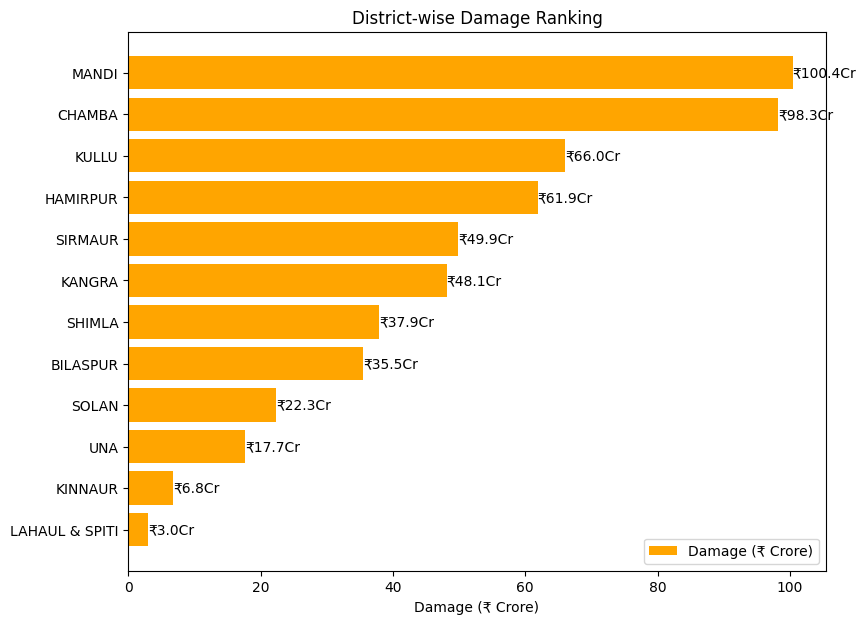

In [22]:
plt.figure(figsize=(9,7))
ax = plt.gca()

sorted_d = dist_dmg.sort_values("Damage_Crore", ascending=True)

bars = ax.barh(
    sorted_d["District"], 
    sorted_d["Damage_Crore"],
    color="orange",
    label="Damage (₹ Crore)"  
)

for bar, val in zip(bars, sorted_d["Damage_Crore"].values):
    ax.text(val, bar.get_y() + bar.get_height()/2,
            f"₹{val:.1f}Cr", va="center")

plt.xlabel("Damage (₹ Crore)")
plt.title("District-wise Damage Ranking")

plt.legend()   
plt.show()

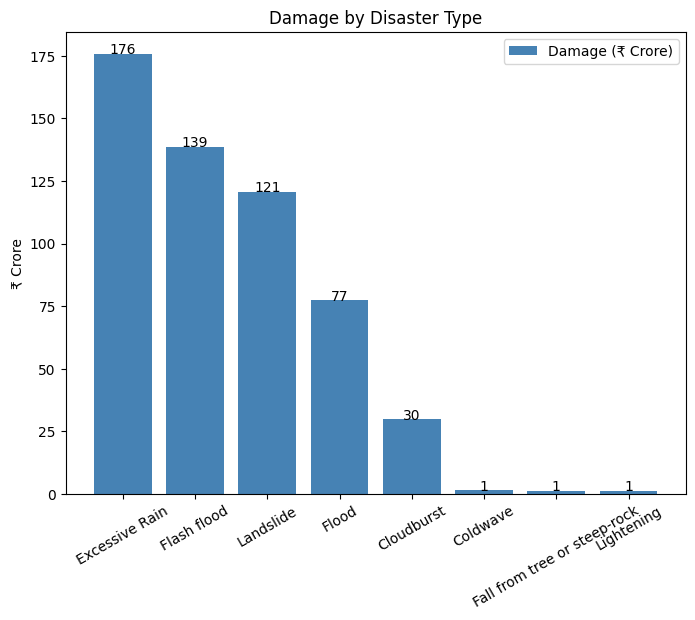

In [23]:
plt.figure(figsize=(8,6))
ax = plt.gca()

dis_cr = dis_type.head(8) / 1e7

bars = ax.bar(
    range(len(dis_cr)), 
    dis_cr.values,
    color="steelblue",
    label="Damage (₹ Crore)"  
)

ax.set_xticks(range(len(dis_cr)))
ax.set_xticklabels(dis_cr.index, rotation=30)

for bar, val in zip(bars, dis_cr.values):
    ax.text(bar.get_x()+bar.get_width()/2, val,
            f"{val:.0f}", ha="center")

plt.ylabel("₹ Crore")
plt.title("Damage by Disaster Type")

plt.legend()
plt.show()